In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
# import importlib
# import src.plots
# importlib.reload(src.plots)
%load_ext autoreload
%autoreload 2
from src.data_preparation import transform_data,prepare_train_test_data,train_logistic_regression,evaluate_model,drop_unused_columns
from src.data_processing import scale_numerical_features
from src.plots import plot_confusion_matrix, plot_confusion_matrices, plot_confusion_matricess,plot_confusion_matrices_tuned
from src.train import train_lightgbm, train_random_forest, train_xgboost
from src.tune import tune_random_forest, tune_lightgbm, tune_xgboost
from src.validate import cross_validate_model

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fraud_df = pd.read_csv("../data/interim/eda_fraud_df.csv")
credit_df = pd.read_csv("../data/interim/eda_credit_df.csv")

In [3]:
columns_to_drop = [
    "user_id",
    "device_id",
    "ip_address",
    "signup_time",
    "purchase_time",
    "day_of_week"
]

fraud_df = drop_unused_columns(
    fraud_df,
    columns_to_drop
)

Dropped columns: ['user_id', 'device_id', 'ip_address', 'signup_time', 'purchase_time', 'day_of_week']


# Model Building and Training
## Data Preparation
### For Fraud Data

In [4]:
numerical_cols = [
    "purchase_value",
    "age"
]
categorical_cols = [
    "source",
    "browser",
    "sex"
]
fraud_df, scaler = transform_data(
    fraud_df,
    numerical_cols,
    categorical_cols
)

In [5]:
X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = (
    prepare_train_test_data(
        fraud_df,
        target_col="class"
    )
)

Training set shape: (120889, 14)
Test set shape: (30223, 14)


In [6]:
print(y_train_fraud.value_counts(normalize=True) * 100)
print(y_test_fraud.value_counts(normalize=True) * 100)

class
0    90.635211
1     9.364789
Name: proportion, dtype: float64
class
0    90.63627
1     9.36373
Name: proportion, dtype: float64


### For Credit Card Data

In [7]:
credit_numerical_cols = [
    "Time", "Amount"
]
credit_df, scaler = scale_numerical_features(
    credit_df,
    credit_numerical_cols
)

In [8]:
X_train_cc, X_test_cc, y_train_cc, y_test_cc = (
    prepare_train_test_data(
        credit_df,
        target_col="Class"
    )
)

Training set shape: (226980, 30)
Test set shape: (56746, 30)


### Apply SMOTE

In [9]:
print(X_train_fraud.select_dtypes(exclude=["number"]).columns)

Index([], dtype='object')


In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_fraud_resampled, y_train_fraud_resampled = (
    smote.fit_resample(
        X_train_fraud,
        y_train_fraud
    )
)

In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_cc_resampled, y_train_cc_resampled = (
    smote.fit_resample(
        X_train_cc,
        y_train_cc
    )
)

## Build Baseline Model(Logistic Regression)
### Fraud Dataset Pipeline
#### Train


In [13]:
fraud_lr = train_logistic_regression(
    X_train_fraud_resampled,
    y_train_fraud_resampled
)

#### Evaluate

In [14]:
fraud_lr_results = evaluate_model(
    fraud_lr,
    X_test_fraud,
    y_test_fraud
)

AUC-PR : 0.2480
F1-Score: 0.2690

Confusion Matrix
[[19380  8013]
 [ 1145  1685]]
0.17374716436378634

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.71      0.81     27393
           1       0.17      0.60      0.27      2830

    accuracy                           0.70     30223
   macro avg       0.56      0.65      0.54     30223
weighted avg       0.87      0.70      0.76     30223



### Credit Card Dataset Pipeline
#### Train

In [15]:
credit_lr = train_logistic_regression(
    X_train_cc_resampled,
    y_train_cc_resampled
)

#### Evaluate

In [16]:
credit_lr_results = evaluate_model(
    credit_lr,
    X_test_cc,
    y_test_cc
)

AUC-PR : 0.6768
F1-Score: 0.1002

Confusion Matrix
[[55172  1479]
 [   12    83]]
0.05313700384122919

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



### Confusion Matrix

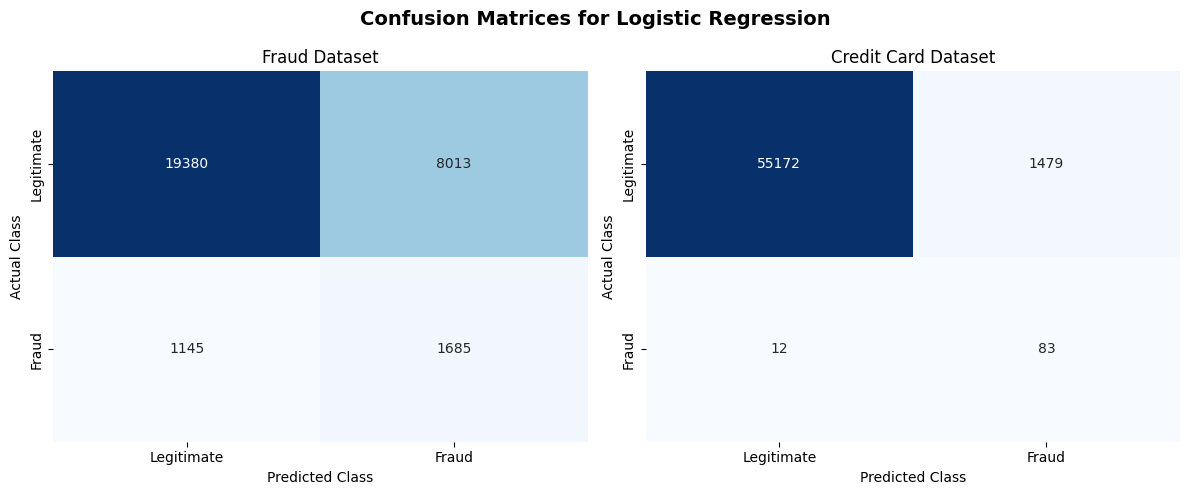

In [17]:
y_pred_fraud = fraud_lr.predict(X_test_fraud)
y_pred_credit = credit_lr.predict(X_test_cc)

plot_confusion_matrices(
    y_test_fraud,
    y_pred_fraud,
    y_test_cc,
    y_pred_credit
)

## Build Ensemble
### Fraud Dataset
#### Train

In [18]:
rf_fraud = train_random_forest(
    X_train_fraud_resampled,
    y_train_fraud_resampled
)

xgb_fraud = train_xgboost(
    X_train_fraud_resampled,
    y_train_fraud_resampled
)

lgbm_fraud = train_lightgbm(
    X_train_fraud_resampled,
    y_train_fraud_resampled
)

[LightGBM] [Info] Number of positive: 109568, number of negative: 109568
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023474 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1058
[LightGBM] [Info] Number of data points in the train set: 219136, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


#### Evaluate

In [19]:
rf_fraud_results = evaluate_model(
    rf_fraud,
    X_test_fraud,
    y_test_fraud
)

xgb_fraud_results = evaluate_model(
    xgb_fraud,
    X_test_fraud,
    y_test_fraud
)

lgbm_fraud_results = evaluate_model(
    lgbm_fraud,
    X_test_fraud,
    y_test_fraud
)

AUC-PR : 0.6272
F1-Score: 0.4484

Confusion Matrix
[[24520  2873]
 [ 1182  1648]]
0.3645211236452112

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.90      0.92     27393
           1       0.36      0.58      0.45      2830

    accuracy                           0.87     30223
   macro avg       0.66      0.74      0.69     30223
weighted avg       0.90      0.87      0.88     30223

AUC-PR : 0.6088
F1-Score: 0.6408

Confusion Matrix
[[26929   464]
 [ 1277  1553]]
0.7699553792761527

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     27393
           1       0.77      0.55      0.64      2830

    accuracy                           0.94     30223
   macro avg       0.86      0.77      0.80     30223
weighted avg       0.94      0.94      0.94     30223

AUC-PR : 0.6288
F1-Score: 0.7015

Confusion Matrix
[[27393     0]
 [ 1301  1529]]
1.0

Classificat

### Credit Card Dataset
#### Train

In [20]:
rf_credit = train_random_forest(
    X_train_cc_resampled,
    y_train_cc_resampled
)

xgb_credit = train_xgboost(
    X_train_cc_resampled,
    y_train_cc_resampled
)

lgbm_credit = train_lightgbm(
    X_train_cc_resampled,
    y_train_cc_resampled
)

[LightGBM] [Info] Number of positive: 226602, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.238119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 453204, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


#### Evaluate

In [21]:
rf_credit_results = evaluate_model(
    rf_credit,
    X_test_cc,
    y_test_cc
)

xgb_credit_results = evaluate_model(
    xgb_credit,
    X_test_cc,
    y_test_cc
)

lgbm_credit_results = evaluate_model(
    lgbm_credit,
    X_test_cc,
    y_test_cc
)

AUC-PR : 0.8037
F1-Score: 0.7749

Confusion Matrix
[[56629    22]
 [   21    74]]
0.7708333333333334

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.77      0.78      0.77        95

    accuracy                           1.00     56746
   macro avg       0.89      0.89      0.89     56746
weighted avg       1.00      1.00      1.00     56746

AUC-PR : 0.8120
F1-Score: 0.7212

Confusion Matrix
[[56613    38]
 [   20    75]]
0.6637168141592921

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.66      0.79      0.72        95

    accuracy                           1.00     56746
   macro avg       0.83      0.89      0.86     56746
weighted avg       1.00      1.00      1.00     56746

AUC-PR : 0.7033
F1-Score: 0.7590

Confusion Matrix
[[56625    26]
 [   21    74]]
0.74

Classifica

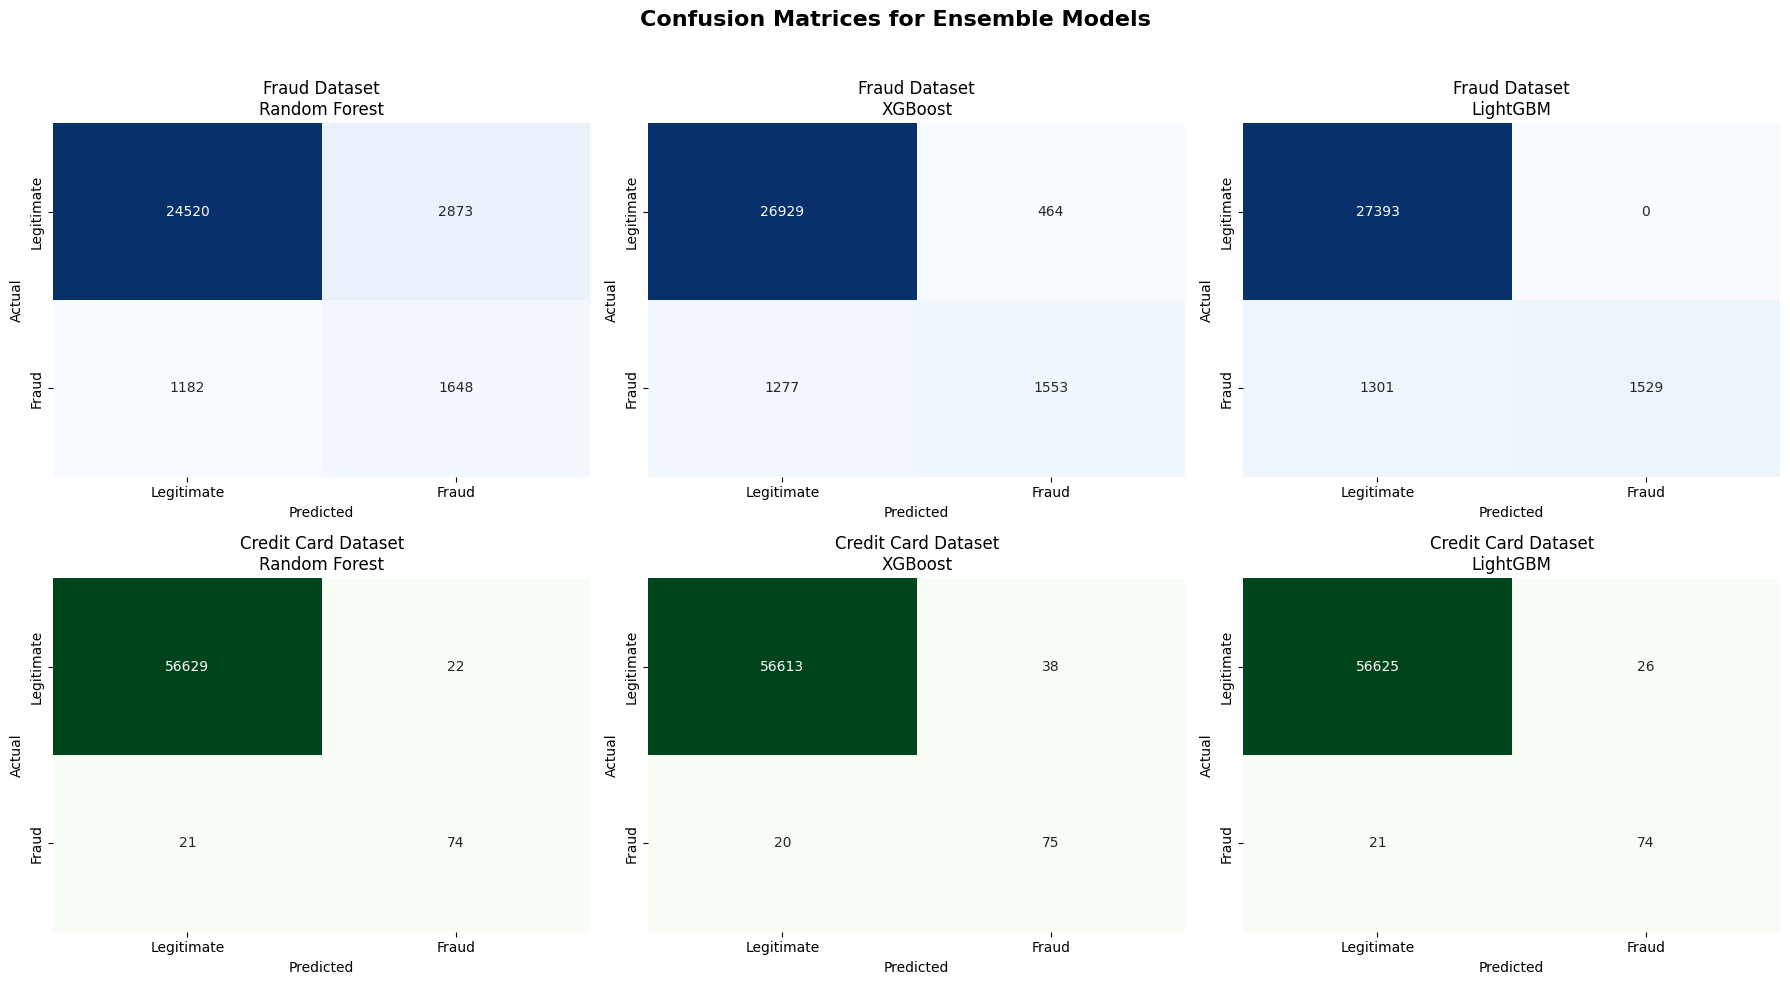

In [22]:
# Fraud predictions
rf_pred_fraud = rf_fraud.predict(X_test_fraud)
xgb_pred_fraud = xgb_fraud.predict(X_test_fraud)
lgbm_pred_fraud = lgbm_fraud.predict(X_test_fraud)

# Credit Card predictions
rf_pred_credit = rf_credit.predict(X_test_cc)
xgb_pred_credit = xgb_credit.predict(X_test_cc)
lgbm_pred_credit = lgbm_credit.predict(X_test_cc)

plot_confusion_matricess(
    y_test_fraud,
    rf_pred_fraud,
    xgb_pred_fraud,
    lgbm_pred_fraud,
    y_test_cc,
    rf_pred_credit,
    xgb_pred_credit,
    lgbm_pred_credit
)

## Tuned Models

### Random Forest

In [16]:
tune_fraud_rf = tune_random_forest(
    X_train_fraud_resampled,
    y_train_fraud_resampled
)

tune_credit_rf = tune_random_forest(
    X_train_cc_resampled,
    y_train_cc_resampled
)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Parameters: {'max_depth': 20, 'n_estimators': 200}
Best F1 Score: 0.8792132070548234
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Parameters: {'max_depth': 20, 'n_estimators': 200}
Best F1 Score: 0.9998433647278112


In [17]:
joblib.dump(tune_fraud_rf, "../models/tune_fraud_rf.pkl")
joblib.dump(tune_credit_rf, "../models/tune_credit_rf.pkl")

['../models/tune_credit_rf.pkl']

###  LightGBM

In [18]:
tune_fraud_lgbm = tune_lightgbm(
    X_train_fraud_resampled,
    y_train_fraud_resampled
)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 20, 'n_estimators': 200}
Best F1 Score: 0.9637099484398746


In [21]:
joblib.dump(tune_fraud_lgbm, "../models/tune_fraud_lgbm.pkl")

['../models/tune_fraud_lgbm.pkl']

### Evaluate
#### Fraud Dataset

In [23]:
tune_fraud_lgbm = joblib.load("../models/tune_fraud_lgbm.pkl")
tune_credit_rf = joblib.load("../models/tune_credit_rf.pkl")

In [24]:
fraud_lgbm_results = evaluate_model(
    tune_fraud_lgbm,
    X_test_fraud,
    y_test_fraud
)

AUC-PR : 0.6278
F1-Score: 0.7015

Confusion Matrix
[[27393     0]
 [ 1301  1529]]
1.0

Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     27393
           1       1.00      0.54      0.70      2830

    accuracy                           0.96     30223
   macro avg       0.98      0.77      0.84     30223
weighted avg       0.96      0.96      0.95     30223



#### Credit Card Dataset

In [25]:
credit_rf_results = evaluate_model(
    tune_credit_rf,
    X_test_cc,
    y_test_cc
)

AUC-PR : 0.8055
F1-Score: 0.8043

Confusion Matrix
[[56636    15]
 [   21    74]]
0.8314606741573034

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.83      0.78      0.80        95

    accuracy                           1.00     56746
   macro avg       0.92      0.89      0.90     56746
weighted avg       1.00      1.00      1.00     56746



#### Confusion Matrix

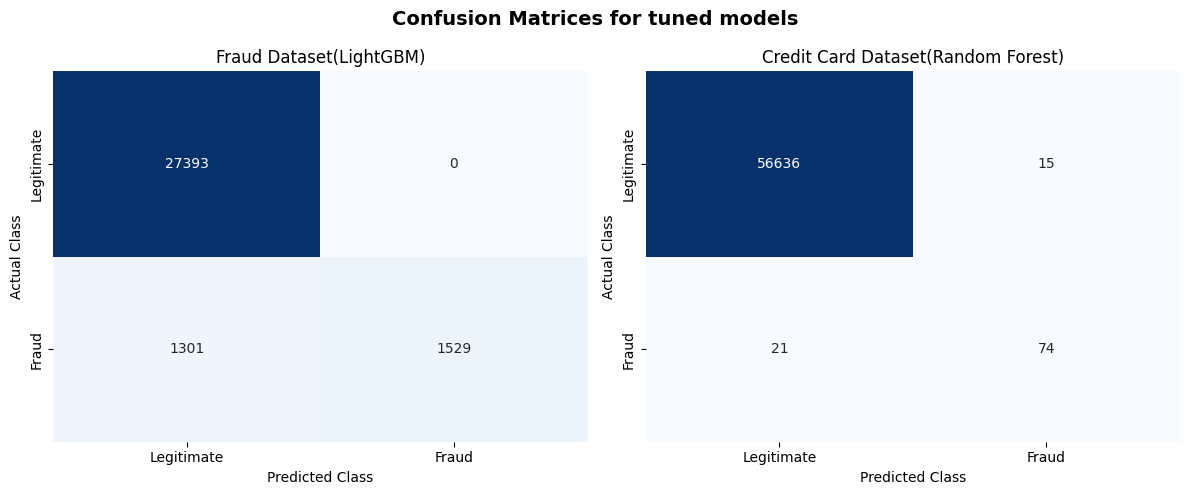

In [35]:
y_pred_fraud = tune_fraud_lgbm.predict(X_test_fraud)
y_pred_credit = tune_credit_rf.predict(X_test_cc)

plot_confusion_matrices_tuned(
    y_test_fraud,
    y_pred_fraud,
    y_test_cc,
    y_pred_credit
)

## Cross Validation
### Fraud Dataset

In [47]:
fraud_lgbm_cv = cross_validate_model(
    tune_fraud_lgbm,
    X_train_fraud,
    y_train_fraud
)

### Credit Card Dataset

In [49]:
credit_rf_cv = cross_validate_model(
    tune_credit_rf,
    X_train_cc,
    y_train_cc
)

In [48]:
fraud_cv_results = pd.DataFrame({
    "LightGBM": fraud_lgbm_cv
}).T

fraud_cv_results

,F1 Mean,F1 Std,Precision Mean,Precision Std,Recall Mean,Recall Std,AUC-PR Mean,AUC-PR Std
LightGBM,0.698027,0.00951,0.999839,0.000323,0.53626,0.011229,0.629174,0.010489


In [50]:
credit_cv_results = pd.DataFrame({
    "Random Forest": credit_rf_cv
}).T

credit_cv_results

,F1 Mean,F1 Std,Precision Mean,Precision Std,Recall Mean,Recall Std,AUC-PR Mean,AUC-PR Std
Random Forest,0.850329,0.045119,0.942938,0.019137,0.777719,0.073462,0.842155,0.034077
